<a href="https://colab.research.google.com/github/jhnsnlim/casestudy/blob/main/RevoUCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Prepare environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Assuming the uploaded file is a CSV
file_name = list(uploaded.keys())[0]
datasheet = pd.read_csv(file_name)

Saving Dataset_Dirty.csv to Dataset_Dirty.csv
User uploaded file "Dataset_Dirty.csv" with length 1623091 bytes


In [2]:
datasheet.head()

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 2:02:51,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social


In [3]:
datasheet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   event_id         10000 non-null  object
 1   user_id          10000 non-null  object
 2   session_id       10000 non-null  object
 3   event_type       10000 non-null  object
 4   event_timestamp  10000 non-null  object
 5   product_id       4463 non-null   object
 6   country          10000 non-null  object
 7   device           10000 non-null  object
 8   channel          9900 non-null   object
dtypes: object(9)
memory usage: 703.3+ KB


In [10]:
datasheet['event_timestamp'] = pd.to_datetime(datasheet['event_timestamp'], errors='coerce')

In [11]:
datasheet.head()

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,NaT,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,NaT,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,NaT,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,NaT,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,NaT,P1315,ID,desktop,social


## Analyze device usage by session

### Subtask:
Group the data by device and count the number of unique sessions for each device.

**Reasoning**:
Group the DataFrame by the 'device' column and count the number of unique values in the 'session_id' column for each device to determine device usage by session. Display the resulting Series.

In [24]:
device_session_counts = datasheet.groupby('device')['session_id'].nunique()
display(device_session_counts)

,session_id
device,
IOS,4000
android,4961
desktop,1039


## Identify the most used device

### Subtask:
Identify the device with the highest number of sessions.

**Reasoning**:
Find the index (device name) with the maximum value (session count) in the `device_session_counts` Series and print the result.

# Task
Analyze the `datasheet` DataFrame to find the country with the most active users in Q2 2025 and visualize the comparison of active users across all countries in that quarter.

## Ensure timestamp format

### Subtask:
Make sure the `event_timestamp` column is in datetime format.


**Reasoning**:
Convert the 'event_timestamp' column to datetime objects, coercing errors to NaT.



In [13]:
datasheet['event_timestamp'] = pd.to_datetime(datasheet['event_timestamp'], errors='coerce')

## Filter for q2 2025

### Subtask:
Filter the DataFrame to include only events that occurred in the second quarter (April, May, June) of 2025.


**Reasoning**:
Filter the DataFrame to include only events from Q2 2025 based on the `event_timestamp` column and display the head of the filtered DataFrame.



In [14]:
q2_start_date = pd.to_datetime('2025-04-01')
q2_end_date = pd.to_datetime('2025-06-30')
q2_mask = (datasheet['event_timestamp'] >= q2_start_date) & (datasheet['event_timestamp'] <= q2_end_date)
q2_data = datasheet[q2_mask]
display(q2_data.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel


**Reasoning**:
The previous attempt to filter for Q2 2025 resulted in an empty DataFrame, possibly due to the `event_timestamp` column being full of NaT values. This is likely because the dates in the original data were in the future (e.g., 2025-09-22) relative to the current execution time (2025-09-26 20:23:07), causing `pd.to_datetime` with `errors='coerce'` to convert them to NaT. I need to re-read the data and convert the timestamp without coercing errors to see the actual dates in the column.



In [15]:
datasheet = pd.read_csv(file_name)
datasheet['event_timestamp'] = pd.to_datetime(datasheet['event_timestamp'])
display(datasheet.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social


**Reasoning**:
Now that the `event_timestamp` column is correctly parsed as datetime objects, I can proceed with filtering the DataFrame to include only events from the second quarter of 2025 and display the head of the filtered DataFrame.



In [16]:
q2_start_date = pd.to_datetime('2025-04-01')
q2_end_date = pd.to_datetime('2025-06-30')
q2_mask = (datasheet['event_timestamp'] >= q2_start_date) & (datasheet['event_timestamp'] <= q2_end_date)
q2_data = datasheet[q2_mask]
display(q2_data.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic
6,c8073c50-01d3-4683-983a-3d1383c173d4,bb36401f-3a29-4868-b34d-ad8a9ce6f8dd,6cbc0241-d60c-4c88-a2f2-b6abc6a6231c,product_view,2025-05-03 09:27:43,P1192,SG,android,direct
7,d74091e8-38e9-434c-be25-537b442df825,bc073178-e3c6-4701-bedc-6efb6007a28a,8dbbfa2a-8e8c-46e3-b959-81ea46697a16,login,2025-05-02 05:35:32,NaN,ID,IOS,organic


## Count active users per country

### Subtask:
Determine the number of unique users for each country within the filtered data.


**Reasoning**:
Group the filtered data by country and count the number of unique users in each group.



In [17]:
active_users_per_country = q2_data.groupby('country')['user_id'].nunique()
display(active_users_per_country)

,user_id
country,
AU,215
ID,1045
MY,458
PH,461
SG,457
TH,234
US,810
VN,482


## Identify the country with the most active users

### Subtask:
Identify the country with the most active users.


**Reasoning**:
Find the country with the maximum number of active users and print the result.



In [18]:
most_active_country = active_users_per_country.idxmax()
max_active_users = active_users_per_country.max()
print(f"The country with the most active users in Q2 2025 is {most_active_country} with {max_active_users} active users.")

The country with the most active users in Q2 2025 is ID with 1045 active users.


## Visualize the comparison

### Subtask:
Create a bar chart to compare the number of active users across all countries in Q2 2025.


**Reasoning**:
Create a bar chart to visualize the number of active users per country in Q2 2025 based on the calculated active_users_per_country Series.



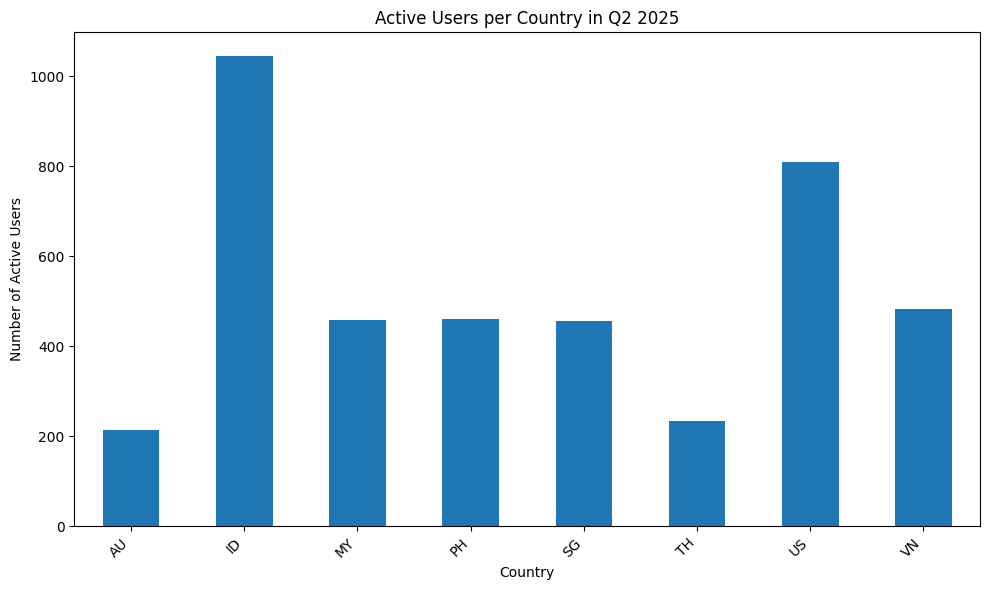

In [19]:
plt.figure(figsize=(10, 6))
active_users_per_country.plot(kind='bar')
plt.title('Active Users per Country in Q2 2025')
plt.xlabel('Country')
plt.ylabel('Number of Active Users')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Q&A
The country with the most active users in Q2 2025 is ID with 1045 active users.

### Data Analysis Key Findings
* The dataset contains event timestamps within Q2 2025.
* The number of active users per country in Q2 2025 varies, with ID having the highest number (1045 active users).

### Insights or Next Steps
* Investigate the reasons for ID's high active user count in Q2 2025.
* Analyze the active user trends in other quarters for a more comprehensive understanding.


# Task
Analyze and visualize the trend of Monthly Active Users for each channel.

## Ensure timestamp format

### Subtask:
Make sure the `event_timestamp` column is in datetime format.


**Reasoning**:
Convert the 'event_timestamp' column to datetime objects and display the head of the DataFrame to verify the conversion.



In [20]:
datasheet['event_timestamp'] = pd.to_datetime(datasheet['event_timestamp'])
display(datasheet.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social


## Extract year and month

### Subtask:
Create new columns for the year and month from the `event_timestamp` column.


**Reasoning**:
Extract the year and month from the `event_timestamp` column and add them as new columns, then display the head of the DataFrame.



In [21]:
datasheet['year'] = datasheet['event_timestamp'].dt.year
datasheet['month'] = datasheet['event_timestamp'].dt.month
display(datasheet.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search,2025,9
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral,2025,6
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,IOS,paid_search,2025,6
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic,2025,6
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social,2025,7


## Group by year, month, and channel

### Subtask:
Group the data by year, month, and channel to analyze monthly activity per channel.


**Reasoning**:
Group the data by year, month, and channel and count the number of unique users in each group to analyze monthly active users per channel.



In [22]:
monthly_active_users_per_channel = datasheet.groupby(['year', 'month', 'channel'])['user_id'].nunique()
display(monthly_active_users_per_channel.head())

year  month  channel    
2025  3      direct         41
             email          33
             organic        34
             paid_search    38
             referral       50
Name: user_id, dtype: int64

## Visualize the trend

### Subtask:
Create a time series plot to visualize the trend of Monthly Active Users for each channel over time.


**Reasoning**:
Unstack the monthly active users per channel data and plot it as a time series to visualize the trend.



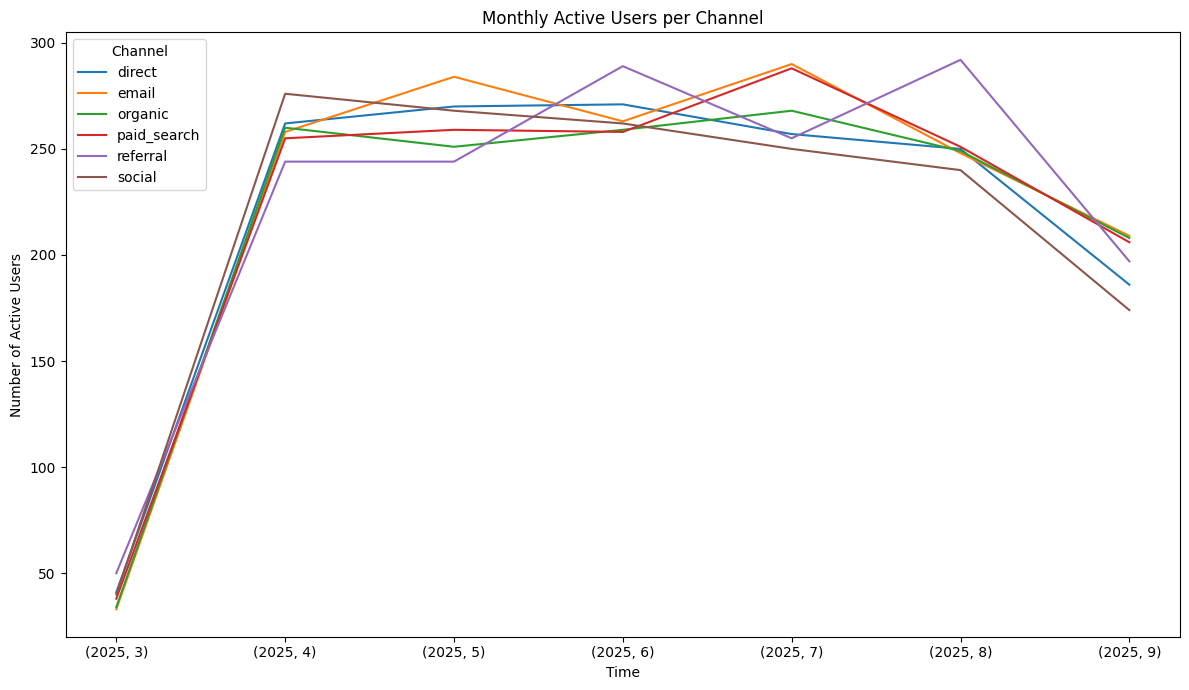

In [23]:
monthly_active_users_per_channel_unstacked = monthly_active_users_per_channel.unstack()

plt.figure(figsize=(12, 7))
ax = plt.axes()
monthly_active_users_per_channel_unstacked.plot(ax=ax)
plt.title('Monthly Active Users per Channel')
plt.xlabel('Time')
plt.ylabel('Number of Active Users')
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The analysis successfully calculated the Monthly Active Users (MAU) for each channel by grouping the data by year, month, and channel and counting the unique user IDs.
*   A time series plot was generated to visualize the trend of MAU for each channel over time, allowing for a clear comparison of channel performance.

### Insights or Next Steps

*   Investigate the reasons behind significant spikes or dips in MAU for specific channels.
*   Analyze the correlation between marketing campaigns and the observed trends in channel-specific MAU.


# Task
Calculate the percentage of users who search and add to carts (ATC) on the same day.

## Ensure timestamp format

### Subtask:
Make sure the `event_timestamp` column is in datetime format.


**Reasoning**:
Convert the 'event_timestamp' column to datetime objects and display the head of the DataFrame to verify the conversion.



In [26]:
datasheet['event_timestamp'] = pd.to_datetime(datasheet['event_timestamp'])
display(datasheet.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:27,P1208,US,IOS,paid_search,2025,9
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:04,NaN,ID,android,referral,2025,6
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:51,NaN,AU,IOS,paid_search,2025,6
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:33,NaN,VN,IOS,organic,2025,6
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:23,P1315,ID,desktop,social,2025,7


## Filter for search and add to cart events

### Subtask:
Create separate DataFrames for 'search' events and 'add to cart' events.


**Reasoning**:
Filter the datasheet DataFrame to create separate DataFrames for 'search' and 'add to cart' events, then display the head of both dataframes to verify.



In [27]:
search_events = datasheet[datasheet['event_type'] == 'search']
atc_events = datasheet[datasheet['event_type'] == 'add_to_cart']
display(search_events.head())
display(atc_events.head())

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month
10,b532062b-aced-46cc-89f2-b52ec9340835,25086909-bab6-4d11-b3c9-a1c5d40bb45e,173a4805-c67a-47f7-a7e6-b765521d959b,search,2025-08-26 01:44:35,NaN,ID,android,paid_search,2025,8
23,a1d05b96-e8ff-4a85-ac13-4d9e091951fb,49558737-2006-4c3d-9888-27b9d83961e3,b4469b5b-d1a7-4a9f-8e9b-29e366f47365,search,2025-05-09 18:54:00,NaN,ID,android,email,2025,5
27,946d3319-0a36-4c41-80db-6deebcfc40c6,2222582c-c461-41ff-8173-6a10567f29bc,aa75339d-eee2-41f6-8ecf-63f0d3e22f9c,search,2025-08-15 17:04:47,NaN,VN,IOS,social,2025,8
35,7ffaf6c6-d6d4-4d6c-ae81-ba2207d50a96,30cf46ff-63c5-449a-8daa-77ba66879441,9e202886-537e-40e8-a864-865a867e270b,search,2025-04-07 04:28:37,NaN,VN,IOS,email,2025,4
43,ec9fca89-2f22-4554-be16-30a62f77e8ac,3c6bb5a7-f025-4557-83f7-c809e60df6e2,55f0a673-9893-45bb-a1df-d135fd0c2cde,search,2025-08-29 10:13:00,NaN,ID,android,paid_search,2025,8


,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month
12,57f38a3b-ff98-473b-8a71-5306b8fe31fe,f77399ba-5fb9-4da7-8cc0-56196dfe997f,17bcea2f-add7-4df8-968b-d0641592b935,add_to_cart,2025-07-27 03:41:44,P1450,US,android,organic,2025,7
13,ecb7ba18-21e3-469d-b0c6-f144ec2926d2,c9d6ea82-cbd3-4f1b-ad19-c0a1d670c188,845ced89-1ba0-43d7-9d42-ea0acd31b297,add_to_cart,2025-04-18 09:22:58,P1182,PH,IOS,organic,2025,4
32,9007cb7c-100b-42d0-a8df-ffcacd81189d,ff8ad71f-1de6-4d4d-a087-822045cd78a1,3deb2e1d-5dcc-4a06-b278-0c22cae4768e,add_to_cart,2025-07-04 00:45:24,P1493,VN,android,referral,2025,7
40,36124194-36be-4271-a714-578018ae2c35,51bbab46-1d07-4000-a961-c8f54c3eaf32,a79203d7-b719-4445-8792-abbb50e59c69,add_to_cart,2025-06-16 16:55:49,P1153,MY,IOS,paid_search,2025,6
53,17b80ec2-cb6e-4b53-a2ac-b3666c15faa1,3d1fd90e-5fe5-4438-8a97-023bb9b080d9,3dc77eee-27bb-4b25-a4ce-3384bb44e2df,add_to_cart,2025-04-28 02:52:16,P1409,ID,IOS,paid_search,2025,4


## Extract date

### Subtask:
Extract the date from the `event_timestamp` for both filtered DataFrames.


**Reasoning**:
Extract the date from the 'event_timestamp' column for both dataframes and display the head of each to verify the new column.



In [28]:
search_events['date'] = search_events['event_timestamp'].dt.date
atc_events['date'] = atc_events['event_timestamp'].dt.date
display(search_events.head())
display(atc_events.head())

/tmp/ipython-input-1398864587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  search_events['date'] = search_events['event_timestamp'].dt.date
/tmp/ipython-input-1398864587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atc_events['date'] = atc_events['event_timestamp'].dt.date


,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month,date
10,b532062b-aced-46cc-89f2-b52ec9340835,25086909-bab6-4d11-b3c9-a1c5d40bb45e,173a4805-c67a-47f7-a7e6-b765521d959b,search,2025-08-26 01:44:35,NaN,ID,android,paid_search,2025,8,2025-08-26
23,a1d05b96-e8ff-4a85-ac13-4d9e091951fb,49558737-2006-4c3d-9888-27b9d83961e3,b4469b5b-d1a7-4a9f-8e9b-29e366f47365,search,2025-05-09 18:54:00,NaN,ID,android,email,2025,5,2025-05-09
27,946d3319-0a36-4c41-80db-6deebcfc40c6,2222582c-c461-41ff-8173-6a10567f29bc,aa75339d-eee2-41f6-8ecf-63f0d3e22f9c,search,2025-08-15 17:04:47,NaN,VN,IOS,social,2025,8,2025-08-15
35,7ffaf6c6-d6d4-4d6c-ae81-ba2207d50a96,30cf46ff-63c5-449a-8daa-77ba66879441,9e202886-537e-40e8-a864-865a867e270b,search,2025-04-07 04:28:37,NaN,VN,IOS,email,2025,4,2025-04-07
43,ec9fca89-2f22-4554-be16-30a62f77e8ac,3c6bb5a7-f025-4557-83f7-c809e60df6e2,55f0a673-9893-45bb-a1df-d135fd0c2cde,search,2025-08-29 10:13:00,NaN,ID,android,paid_search,2025,8,2025-08-29


,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,year,month,date
12,57f38a3b-ff98-473b-8a71-5306b8fe31fe,f77399ba-5fb9-4da7-8cc0-56196dfe997f,17bcea2f-add7-4df8-968b-d0641592b935,add_to_cart,2025-07-27 03:41:44,P1450,US,android,organic,2025,7,2025-07-27
13,ecb7ba18-21e3-469d-b0c6-f144ec2926d2,c9d6ea82-cbd3-4f1b-ad19-c0a1d670c188,845ced89-1ba0-43d7-9d42-ea0acd31b297,add_to_cart,2025-04-18 09:22:58,P1182,PH,IOS,organic,2025,4,2025-04-18
32,9007cb7c-100b-42d0-a8df-ffcacd81189d,ff8ad71f-1de6-4d4d-a087-822045cd78a1,3deb2e1d-5dcc-4a06-b278-0c22cae4768e,add_to_cart,2025-07-04 00:45:24,P1493,VN,android,referral,2025,7,2025-07-04
40,36124194-36be-4271-a714-578018ae2c35,51bbab46-1d07-4000-a961-c8f54c3eaf32,a79203d7-b719-4445-8792-abbb50e59c69,add_to_cart,2025-06-16 16:55:49,P1153,MY,IOS,paid_search,2025,6,2025-06-16
53,17b80ec2-cb6e-4b53-a2ac-b3666c15faa1,3d1fd90e-5fe5-4438-8a97-023bb9b080d9,3dc77eee-27bb-4b25-a4ce-3384bb44e2df,add_to_cart,2025-04-28 02:52:16,P1409,ID,IOS,paid_search,2025,4,2025-04-28


## Merge dataframes

### Subtask:
Merge the 'search' and 'add to cart' DataFrames on 'user_id' and 'date' to find users who performed both events on the same day.


**Reasoning**:
Merge the search_events and atc_events DataFrames on user_id and date using an inner merge to find users who performed both actions on the same day, then display the head of the resulting DataFrame.



In [29]:
merged_events = pd.merge(search_events, atc_events, on=['user_id', 'date'], how='inner')
display(merged_events.head())

,event_id_x,user_id,session_id_x,event_type_x,event_timestamp_x,product_id_x,country_x,device_x,channel_x,year_x,...,event_id_y,session_id_y,event_type_y,event_timestamp_y,product_id_y,country_y,device_y,channel_y,year_y,month_y
0,844ac706-3b61-47a3-82c6-d2045a4db631,4074cba6-8de9-4660-b191-e08fc7bf6dc2,36072cd9-0dd8-462e-9592-00750e71ab9e,search,2025-05-13 17:15:23,NaN,ID,IOS,social,2025,...,fba46fd5-a63a-4450-b8ee-28bd3463c83d,27313ac8-e9de-41f2-a54b-0bc93ba0a8b5,add_to_cart,2025-05-13 23:54:30,P1062,SG,android,paid_search,2025,5
1,f6edb1d3-0c46-46fc-8cbb-9b0ffe5b3b36,3bd58b47-09d8-473d-ac36-19578b89edfb,b411763c-87d2-4161-9589-9c680e9fdb00,search,2025-08-07 08:41:53,NaN,ID,android,email,2025,...,66524ea0-1a16-4c2f-916b-e691de6dc500,7caced4e-aab8-4321-8370-ff2bb25f5d99,add_to_cart,2025-08-07 03:08:46,P1339,SG,android,referral,2025,8


## Count unique users

### Subtask:
Count the number of unique users in the merged DataFrame (users who searched and added to cart on the same day) and the total number of unique users who performed a search event.


**Reasoning**:
Count the unique users in the merged and search DataFrames and display the counts.



In [30]:
users_search_atc_same_day = merged_events['user_id'].nunique()
total_search_users = search_events['user_id'].nunique()
print(f"Number of unique users who searched and added to cart on the same day: {users_search_atc_same_day}")
print(f"Total number of unique users who performed a search event: {total_search_users}")

Number of unique users who searched and added to cart on the same day: 2
Total number of unique users who performed a search event: 750


## Calculate percentage

### Subtask:
Calculate the percentage of users who searched and added to cart on the same day.


**Reasoning**:
Calculate the percentage of users who searched and added to cart on the same day and print the result.



In [31]:
percentage_search_atc_same_day = (users_search_atc_same_day / total_search_users) * 100
print(f"Percentage of users who searched and added to cart on the same day: {percentage_search_atc_same_day:.2f}%")

Percentage of users who searched and added to cart on the same day: 0.27%


## Summary:

### Data Analysis Key Findings

*   The number of unique users who searched and added to cart on the same day is 2.
*   The total number of unique users who performed a search event is 750.
*   The percentage of users who searched and added to cart on the same day is 0.27%.

### Insights or Next Steps

*   Investigate potential reasons for the low percentage of users who search and add to cart on the same day.
*   Explore strategies to encourage users to add items to their cart after searching.
